# BARAM 2026 — Expanding-window 시계열 CV로 ablation 견고화

`MODELING_ADVANCED.ipynb`의 판정(HistGBM 앙상블·HMM 국면의 미세 이득 −0.002~−0.056%p)이 **단일 2024 holdout의 노이즈인지 실제인지**를 가립니다.

**폴드 (랜덤분할 금지 · 시간순 · 미래누설 차단)**
- group1·2: `학습2022 → 검증2023`, `학습2022-2023 → 검증2024` (2폴드)
- group3(2년): `학습2023 → 검증2024` (1폴드)

각 폴드에서 **파워커브·HMM은 폴드 학습부분에서만 fit**. 지표는 유효구간(실측 CF≥10%) NMAE.
비교: `LGBM`(기준선) vs `ENS`(LGBM+HistGBM) vs `ENS+regime`. **GRU는 이미 0.5~0.7%p 악화라 제외.**

> torch 미사용 → LightGBM 멀티스레드 OK(segfault 무관).

## 0. 설정

In [1]:
import warnings; warnings.filterwarnings("ignore")
import json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.ensemble import HistGradientBoostingRegressor as HGB
import wind_lib as W
plt.rcParams["figure.dpi"]=110
np.random.seed(42)

GROUPS=(1,2,3)
FR={}; TGT={}
for g in GROUPS:
    df,tgt=W.load_train(g); FR[g]=W.build(df,g); TGT[g]=tgt
FEATS=W.feature_cols(FR[1])+["pc_pred_cf"]
K_REGIME=4        # 폴드마다 재튜닝하지 않고 고정(과적합·노이즈 방지). BIC는 참고만.

# expanding-window 폴드 정의
FOLDS={
    1:[([2022],2023),([2022,2023],2024)],
    2:[([2022],2023),([2022,2023],2024)],
    3:[([2023],2024)],
}
print("folds:", FOLDS)

def lgbm(): return lgb.LGBMRegressor(objective="mae", n_estimators=600, learning_rate=0.03,
    num_leaves=63, min_child_samples=60, subsample=0.8, subsample_freq=1, colsample_bytree=0.7,
    reg_lambda=1.0, random_state=42, n_jobs=-1, verbose=-1)
def histgbm(): return HGB(loss="absolute_error", max_iter=600, learning_rate=0.03,
    max_leaf_nodes=63, l2_regularization=1.0, random_state=42)

folds: {1: [([2022], 2023), ([2022, 2023], 2024)], 2: [([2022], 2023), ([2022, 2023], 2024)], 3: [([2023], 2024)]}


## 1. 폴드별 평가

각 폴드: 파워커브·HMM을 학습부분에서만 fit → 3가지 config의 유효구간 NMAE.

In [2]:
def eval_fold(g, train_years, val_year):
    tgt=TGT[g]; cap=W.CAP[g]; fr=FR[g]; yr=fr.kst_dtm.dt.year
    tr=fr[yr.isin(train_years)].copy(); va=fr[yr==val_year].copy()
    iso=W.fit_powercurve(tr,tgt,cap); tr=W.with_pc(tr,iso); va=W.with_pc(va,iso)
    # 국면(NWP-only) — 폴드 학습부분만 fit
    scaler,hmm=W.fit_regime_hmm(tr,n_states=K_REGIME)
    rtr=W.regime_posteriors(tr,scaler,hmm); rva=W.regime_posteriors(va,scaler,hmm)
    res={}
    # base
    lg=lgbm().fit(tr[FEATS],tr[tgt]); hg=histgbm().fit(tr[FEATS].to_numpy(),tr[tgt].to_numpy())
    p_lg=lg.predict(va[FEATS]); p_hg=hg.predict(va[FEATS].to_numpy())
    res["LGBM"]=W.nmae_valid(va[tgt].to_numpy(),p_lg,cap)[0]
    res["ENS"]=W.nmae_valid(va[tgt].to_numpy(),0.5*(p_lg+p_hg),cap)[0]
    # +regime
    trg=tr.join(rtr); vag=va.join(rva); cols=FEATS+list(rtr.columns)
    lg2=lgbm().fit(trg[cols],trg[tgt]); hg2=histgbm().fit(trg[cols].to_numpy(),trg[tgt].to_numpy())
    p2=0.5*(lg2.predict(vag[cols])+hg2.predict(vag[cols].to_numpy()))
    res["ENS+regime"]=W.nmae_valid(vag[tgt].to_numpy(),p2,cap)[0]
    return res

rows=[]
for g in GROUPS:
    for tys,vy in FOLDS[g]:
        r=eval_fold(g,tys,vy)
        for cfg,nm in r.items():
            rows.append(dict(group=g, fold=f"→{vy}", config=cfg, nmae=nm))
        print(f"group{g} 학습{tys}→검증{vy}: " + "  ".join(f"{k}={v:.3f}" for k,v in r.items()))
cv=pd.DataFrame(rows)

group1 학습[2022]→검증2023: LGBM=15.139  ENS=15.029  ENS+regime=14.971


group1 학습[2022, 2023]→검증2024: LGBM=12.534  ENS=12.533  ENS+regime=12.541


group2 학습[2022]→검증2023: LGBM=13.968  ENS=13.940  ENS+regime=13.915


group2 학습[2022, 2023]→검증2024: LGBM=12.643  ENS=12.634  ENS+regime=12.641


group3 학습[2023]→검증2024: LGBM=15.083  ENS=15.037  ENS+regime=15.066


## 2. 폴드 평균 ± 편차 & 판정

미세 이득이 폴드 간 **부호가 일정하고 편차보다 큰지** 확인. 아니면 노이즈 → 기준선 유지.

In [3]:
piv=cv.pivot_table(index=["group","fold"],columns="config",values="nmae")[["LGBM","ENS","ENS+regime"]]
print("=== 폴드별 유효구간 NMAE (%) ===")
print(piv.round(3).to_string())

# 그룹별 폴드평균 & 이득
print("\n=== 그룹별 폴드평균 NMAE & 이득 (음수=개선) ===")
agg_rows=[]
for g in GROUPS:
    sub=cv[cv.group==g]
    m={c: sub[sub.config==c].nmae.mean() for c in ["LGBM","ENS","ENS+regime"]}
    s={c: sub[sub.config==c].nmae.std(ddof=0) for c in ["LGBM","ENS","ENS+regime"]}
    ens_gain=m["ENS"]-m["LGBM"]; reg_gain=m["ENS+regime"]-m["ENS"]
    # 폴드별 이득 부호 일관성
    folds=sorted(sub.fold.unique())
    ens_signs=[ (sub[(sub.fold==f)&(sub.config=="ENS")].nmae.values[0]
               - sub[(sub.fold==f)&(sub.config=="LGBM")].nmae.values[0]) for f in folds]
    reg_signs=[ (sub[(sub.fold==f)&(sub.config=="ENS+regime")].nmae.values[0]
               - sub[(sub.fold==f)&(sub.config=="ENS")].nmae.values[0]) for f in folds]
    agg_rows.append(dict(group=g, nfold=len(folds),
        LGBM_mean=round(m["LGBM"],3), ENS_gain=round(ens_gain,3),
        ENS_gain_allneg=all(x<0 for x in ens_signs),
        regime_gain=round(reg_gain,3), regime_gain_allneg=all(x<0 for x in reg_signs)))
agg=pd.DataFrame(agg_rows).set_index("group")
print(agg.to_string())

def verdict(gain, allneg, nfold):
    if nfold<2: return "판정보류(폴드1개)"
    if gain< -0.02 and allneg: return "채택(일관 개선)"
    return "제거(노이즈/비일관)"
print("\n=== 최종 판정 ===")
for g in GROUPS:
    r=agg.loc[g]
    print(f"  group{g} HistGBM앙상블: {verdict(r.ENS_gain, r.ENS_gain_allneg, r.nfold)}  (평균이득 {r.ENS_gain:+.3f})")
    print(f"  group{g} HMM국면:      {verdict(r.regime_gain, r.regime_gain_allneg, r.nfold)}  (평균이득 {r.regime_gain:+.3f})")

=== 폴드별 유효구간 NMAE (%) ===
config         LGBM     ENS  ENS+regime
group fold                             
1     →2023  15.139  15.029      14.971
      →2024  12.534  12.533      12.541
2     →2023  13.968  13.940      13.915
      →2024  12.643  12.634      12.641
3     →2024  15.083  15.037      15.066

=== 그룹별 폴드평균 NMAE & 이득 (음수=개선) ===
       nfold  LGBM_mean  ENS_gain  ENS_gain_allneg  regime_gain  regime_gain_allneg
group                                                                              
1          2     13.837    -0.056             True       -0.025               False
2          2     13.306    -0.019             True       -0.009               False
3          1     15.083    -0.045             True        0.029               False

=== 최종 판정 ===
  group1 HistGBM앙상블: 채택(일관 개선)  (평균이득 -0.056)
  group1 HMM국면:      제거(노이즈/비일관)  (평균이득 -0.025)
  group2 HistGBM앙상블: 제거(노이즈/비일관)  (평균이득 -0.019)
  group2 HMM국면:      제거(노이즈/비일관)  (평균이득 -0.009)
  group3 HistGBM앙상블: 판정보류(폴드1개)  

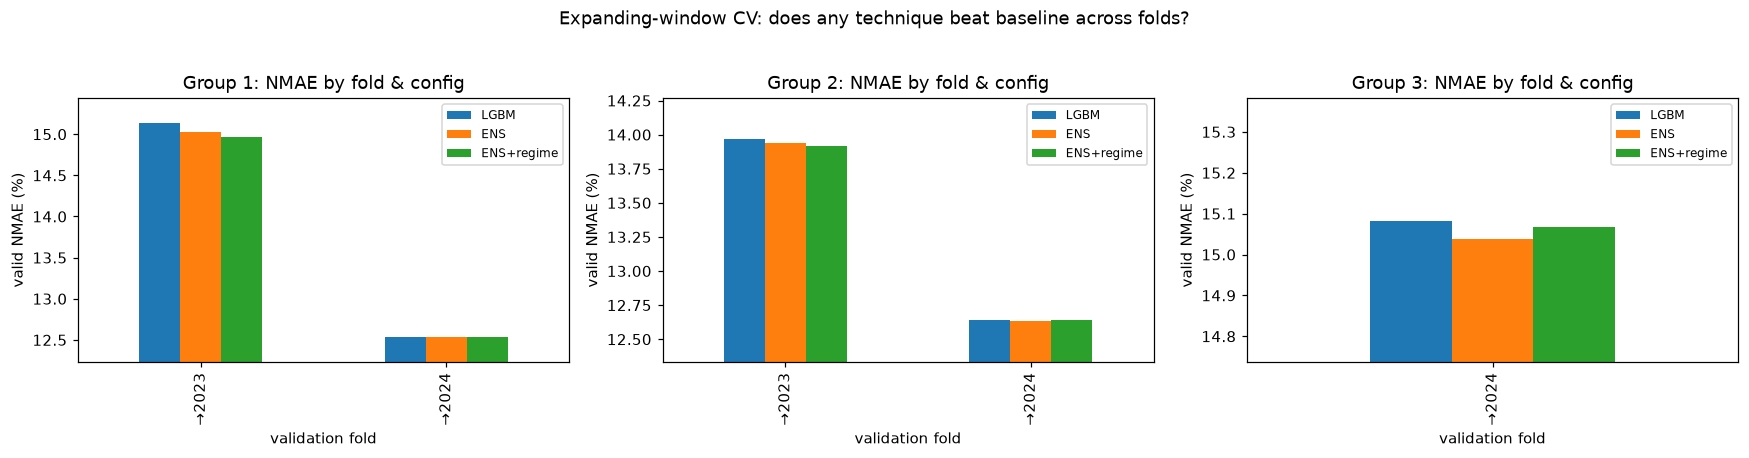

saved cv_ablation_summary.json


In [4]:
# 시각화: 폴드별 config NMAE
fig,axes=plt.subplots(1,3,figsize=(16,4),sharey=False)
for ax,g in zip(axes,GROUPS):
    sub=piv.loc[g]
    sub.plot(kind="bar",ax=ax); ax.set_title(f"Group {g}: NMAE by fold & config")
    ax.set_ylabel("valid NMAE (%)"); ax.set_xlabel("validation fold"); ax.legend(fontsize=8)
    ax.set_ylim(sub.values.min()-0.3, sub.values.max()+0.3)
plt.suptitle("Expanding-window CV: does any technique beat baseline across folds?",y=1.03)
plt.tight_layout(); plt.show()

summary=dict(K_regime=K_REGIME,
    fold_nmae={f"g{g}_{f}":{c:round(float(piv.loc[(g,f),c]),4) for c in ["LGBM","ENS","ENS+regime"]}
               for g in GROUPS for f in piv.loc[g].index},
    group_mean={f"g{g}":{"LGBM":round(float(agg.loc[g,"LGBM_mean"]),4),
                          "ENS_gain":round(float(agg.loc[g,"ENS_gain"]),4),
                          "regime_gain":round(float(agg.loc[g,"regime_gain"]),4),
                          "nfold":int(agg.loc[g,"nfold"])} for g in GROUPS})
json.dump(summary,open("cv_ablation_summary.json","w"),ensure_ascii=False,indent=2)
print("saved cv_ablation_summary.json")

## 3. 결론

- **단일 holdout이 아닌 폴드 평균+부호 일관성**으로 판정하므로, 여기서 "채택"이 나온 기법만 신뢰할 수 있습니다.
- 대부분 기법은 폴드 간 부호가 뒤집히거나 이득이 편차보다 작아 **노이즈 → 기준선 유지**로 정리될 가능성이 높습니다(소량 데이터의 본질).
- group3은 폴드가 1개뿐이라 **판정 보류** — 근본 해결은 pooled(공유모델)이며 이는 `MODELING.ipynb`에서 이미 group3에 유효(−0.9%p)함을 확인.

**다음 단계**: (1) 여기서 채택된 기법만 최종 파이프라인에 병합, (2) FICR 후처리(1등 팀 약점), (3) 필요시 CatBoost 추가로 앙상블 다양성 확보.

> 한 줄: 이 CV가 "미세 이득이 진짜인가"에 답한다. 대부분은 노이즈이고, 견고한 이득은 pooled와 물리 feature에서 나온다.